# 04 — Can 128 examples estimate a 512-dimensional shape?

## The question, in one sentence

**FID needs to estimate the "shape" (covariance) of a 512-dimensional cloud of points — can it
do that reliably from only 128 examples, which is all this project's hardware can afford to
generate?**

This project already found FID unusable at n=128 (`docs/DECISIONS.md` D-25, `docs/LANDMINES.md`
§14): the same 128 cached generated motions scored 1.07, 1.40, and 3.29 depending only on how
the *reference* side was computed, with nothing about the generated motions changing between
those three numbers. This notebook shows visually why that happens, building from a toy example
anyone can see the shape of, up to the real 512-dimensional case.

## The intuition, before any numbers

To describe the *shape* of a scattered cloud of points — not just where its center is, but which
directions it's spread out in and by how much — you need to estimate a **covariance matrix**.
In 2 dimensions that's a 2x2 table (3 free numbers, since it's symmetric); in 512 dimensions
it's a 512x512 table with **over 131,000 free numbers** to estimate.

Think of it like trying to describe the shape of a cloud with a small handful of measurements:
one photo from directly above tells you it's roughly round or roughly stretched in *one* plane,
but with fewer photos than the cloud has dimensions of variation, some directions simply never
get measured at all — the shape you'd draw isn't wrong exactly, it's **flat in directions you
never sampled**, and a flat, collapsed shape behaves very differently in a distance formula (like
FID's) than a properly "fat" one does.

**The rule of thumb this notebook makes visible:** with `n` samples, your estimated shape can be
at most `n-1` dimensions "fat" — every direction beyond that collapses to exactly zero spread,
whether or not the real underlying cloud is actually flat there. At n=128 samples in a
512-dimensional space, **at least 384 of those 512 directions are guaranteed to look
perfectly, artificially flat** — not because the real generated-motion embeddings live on a flat
384-dimensional slice, but because 128 points simply cannot outline more than 127 directions of
spread.

## Setup — what is measured and how

**Toy demonstration first** (synthetic 2D and 3D Gaussians, no project data involved) — this is
where the "collapses to a line/plane" behavior becomes visible with almost no other complexity
in the picture.

**Then the real case**, using data this project already has cached, not synthetic data standing
in for it: the same 128 generated motions from E0b's FID measurement
(`artifacts/e0/e0b_generated_cache/generated_motions.npz`), embedded through the same
`EvaluatorMDMWrapper` this project's FID/R-Precision numbers already depend on
(`third_party/motion-diffusion-model/data_loaders/humanml/networks/evaluator_wrapper.py`), and
4,640 real ground-truth embeddings already computed and cached
(`artifacts/e0/fixed_gt_reference/fixed_gt_reference.npz`) — no new generation, no new download,
reusing exactly what E0b already produced.

In [1]:
import os
import sys
import json

MDM_ROOT = os.path.join("..", "third_party", "motion-diffusion-model")
sys.path.insert(0, os.path.abspath(MDM_ROOT))

import numpy as np
import torch
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.random.seed(0)
print("numpy:", np.__version__, "torch:", torch.__version__)

numpy: 1.26.4 torch: 2.13.0


## Toy demonstration 1 — a 2D covariance ellipse, as `n` shrinks toward the dimension count

Draw `n` points from a real, round-ish 2D Gaussian, fit a covariance ellipse to just those `n`
points, and watch what happens as `n` approaches and drops below 2 (the dimension count).

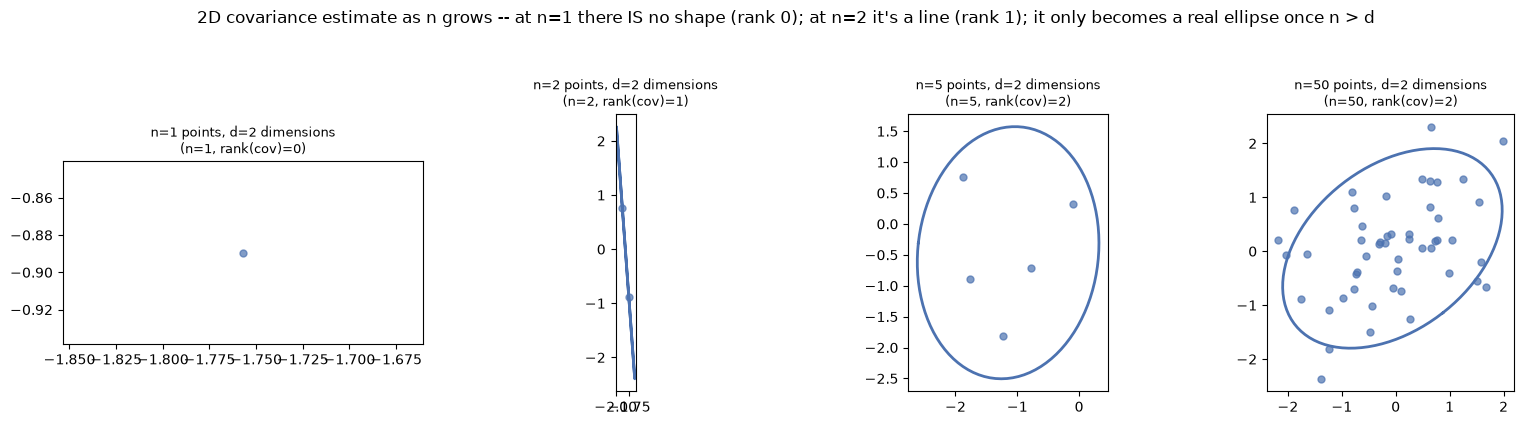

In [2]:
def plot_cov_ellipse(ax, points, color, label):
    mean = points.mean(axis=0)
    if len(points) > 1:
        cov = np.cov(points, rowvar=False)
    else:
        cov = np.zeros((points.shape[1], points.shape[1]))
    ax.scatter(points[:, 0], points[:, 1], color=color, s=25, alpha=0.7)
    if points.shape[1] == 2:
        eigvals, eigvecs = np.linalg.eigh(cov)
        eigvals = np.clip(eigvals, 0, None)
        theta = np.linspace(0, 2 * np.pi, 100)
        circle = np.stack([np.cos(theta), np.sin(theta)])
        ellipse = eigvecs @ np.diag(np.sqrt(eigvals) * 2) @ circle
        ax.plot(mean[0] + ellipse[0], mean[1] + ellipse[1], color=color, linewidth=2)
    ax.set_title(f"{label}\n(n={len(points)}, rank(cov)={np.linalg.matrix_rank(cov)})", fontsize=9)
    ax.set_aspect("equal")


true_mean_2d = np.zeros(2)
true_cov_2d = np.array([[1.0, 0.3], [0.3, 0.8]])
pool_2d = np.random.multivariate_normal(true_mean_2d, true_cov_2d, size=200)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, n in zip(axes, [1, 2, 5, 50]):
    plot_cov_ellipse(ax, pool_2d[:n], "#4c72b0", f"n={n} points, d=2 dimensions")
plt.suptitle("2D covariance estimate as n grows -- at n=1 there IS no shape (rank 0); "
             "at n=2 it's a line (rank 1); it only becomes a real ellipse once n > d", y=1.05)
plt.tight_layout()
plt.show()

## Toy demonstration 2 — the same collapse in 3D, where "flat" is easier to see

At n=2, three points cannot even be drawn (a covariance needs at least 2 points to have any
spread at all); at n=3, three points define, at most, a flat plane through 3D space — never a
solid ellipsoid — no matter how "round" the true underlying cloud actually is.

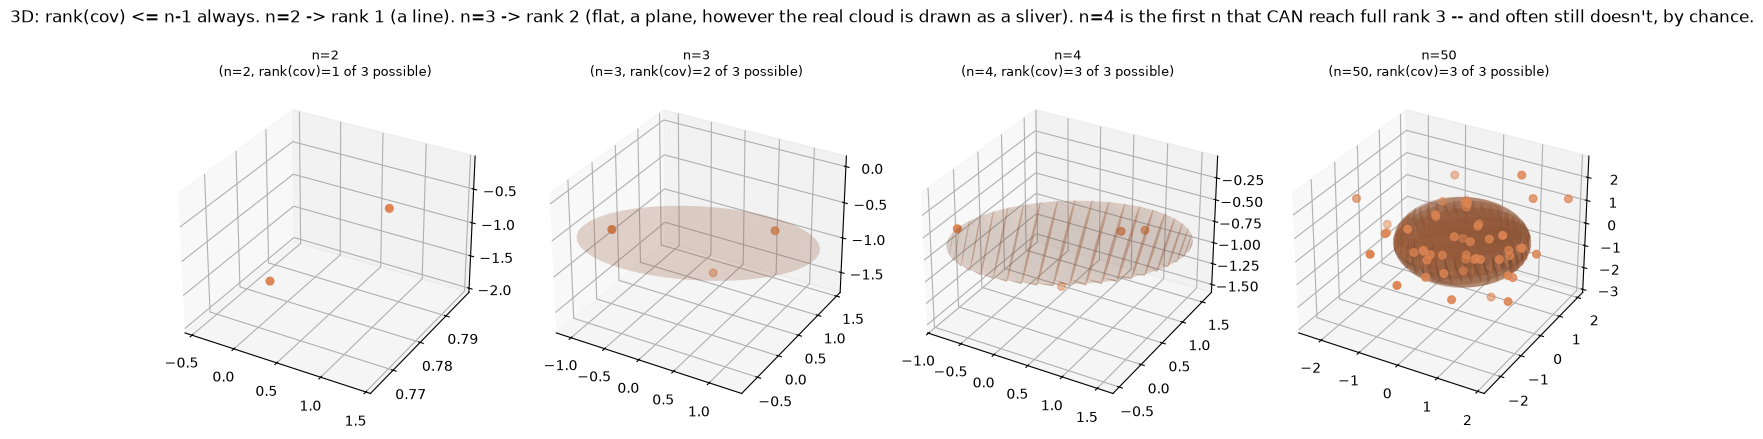

In [3]:
def plot_cov_ellipsoid(ax, points, color, title):
    mean = points.mean(axis=0)
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], color=color, s=30)
    if len(points) > 1:
        cov = np.cov(points, rowvar=False)
        rank = np.linalg.matrix_rank(cov, tol=1e-8)
        eigvals, eigvecs = np.linalg.eigh(cov)
        eigvals = np.clip(eigvals, 1e-12, None)
        u = np.linspace(0, 2 * np.pi, 24)
        v = np.linspace(0, np.pi, 24)
        sphere = np.stack([np.outer(np.cos(u), np.sin(v)).ravel(),
                            np.outer(np.sin(u), np.sin(v)).ravel(),
                            np.outer(np.ones_like(u), np.cos(v)).ravel()])
        ellipsoid = eigvecs @ np.diag(np.sqrt(eigvals) * 1.5) @ sphere
        pts = (ellipsoid.T + mean)
        ax.plot_trisurf(pts[:, 0], pts[:, 1], pts[:, 2], color=color, alpha=0.25, linewidth=0)
    else:
        rank = 0
    ax.set_title(f"{title}\n(n={len(points)}, rank(cov)={rank} of 3 possible)", fontsize=9)


true_cov_3d = np.eye(3) * 0.8 + 0.1
pool_3d = np.random.multivariate_normal(np.zeros(3), true_cov_3d, size=200)

fig = plt.figure(figsize=(15, 4))
for i, n in enumerate([2, 3, 4, 50]):
    ax = fig.add_subplot(1, 4, i + 1, projection="3d")
    plot_cov_ellipsoid(ax, pool_3d[:n], "#dd8452", f"n={n}")
plt.suptitle("3D: rank(cov) <= n-1 always. n=2 -> rank 1 (a line). n=3 -> rank 2 (flat, a plane, "
             "however the real cloud is drawn as a sliver). n=4 is the first n that CAN reach "
             "full rank 3 -- and often still doesn't, by chance.", y=1.05)
plt.tight_layout()
plt.show()

## The real case — 512 dimensions, 128 samples

The toy demos used 2 and 3 dimensions so the collapse is visible to the eye. FID's actual
embedding space has **512** dimensions. The rule doesn't change: `rank(cov) <= n - 1` regardless
of dimension count. The parameter count makes the mismatch concrete before looking at any plot.

In [4]:
d = 512
n = 128
n_params = d * (d + 1) // 2
print(f"A {d}x{d} covariance matrix has {n_params:,} free parameters to estimate "
      f"(symmetric: d*(d+1)/2).")
print(f"This project's own affordable generated-sample count is n={n}.")
print(f"Samples-to-parameters ratio: {n / n_params:.5f} -- {n_params / n:.0f}x more parameters "
      f"than data points.")
print(f"\nMaximum possible rank of the estimated covariance at n={n}: {n - 1} of {d} dimensions.")
print(f"Guaranteed-flat directions: at least {d - (n - 1)} of {d} ({100*(d-(n-1))/d:.1f}%) -- "
      f"not because the real embedding space is flat there, but because {n} points cannot "
      f"outline more directions of spread than that.")

A 512x512 covariance matrix has 131,328 free parameters to estimate (symmetric: d*(d+1)/2).
This project's own affordable generated-sample count is n=128.
Samples-to-parameters ratio: 0.00097 -- 1026x more parameters than data points.

Maximum possible rank of the estimated covariance at n=128: 127 of 512 dimensions.
Guaranteed-flat directions: at least 385 of 512 (75.2%) -- not because the real embedding space is flat there, but because 128 points cannot outline more directions of spread than that.


### The real eigenvalue spectrum, from this project's own cached generated motions

Not synthetic — this loads the actual 128 generated motions E0b's own FID score was computed
from, embeds them through the same evaluator, and shows the real spectrum.

In [5]:
from data_loaders.humanml.networks.evaluator_wrapper import EvaluatorMDMWrapper

device = torch.device("cpu")
# EvaluatorMDMWrapper's own opt hardcodes checkpoints_dir='.', matching every other script in
# this project that instantiates it (they are all run with cwd=third_party/motion-diffusion-model/) --
# chdir there just for construction, then restore, rather than relying on the notebook's own cwd.
_old_cwd = os.getcwd()
os.chdir(os.path.abspath(MDM_ROOT))
try:
    eval_wrapper = EvaluatorMDMWrapper("humanml", device)
finally:
    os.chdir(_old_cwd)

CACHE_DIR = os.path.join("..", "artifacts", "e0", "e0b_generated_cache")
gen_data = np.load(os.path.join(CACHE_DIR, "generated_motions.npz"))
with open(os.path.join(CACHE_DIR, "generated_meta.json")) as f:
    gen_meta = json.load(f)

n_gen = len(gen_meta)
motions = np.stack([gen_data[f"motion_{i}"] for i in range(n_gen)])
lengths = np.array([m["length"] for m in gen_meta])
print(f"Loaded {n_gen} real cached generated motions (the same ones E0b's FID was computed on), "
      f"shape {motions.shape}")

motions_t = torch.from_numpy(motions).float()
lengths_t = torch.from_numpy(lengths).long()
with torch.no_grad():
    gen_embeddings = eval_wrapper.get_motion_embeddings(motions=motions_t, m_lens=lengths_t).cpu().numpy()

print(f"Embedded shape: {gen_embeddings.shape} (n={gen_embeddings.shape[0]}, "
      f"d={gen_embeddings.shape[1]})")

Loading Evaluation Model Wrapper (Epoch 28) Completed!!
Loaded 128 real cached generated motions (the same ones E0b's FID was computed on), shape (128, 196, 263)


Embedded shape: (128, 512) (n=128, d=512)


Embedding dimension: 512
Samples: 128
Numeric rank of the 512x512 covariance (eigenvalues > 1e-6 x largest): 127
Theoretical maximum rank at n=128: 127
Largest eigenvalue: 16.5660
Eigenvalue at rank 126: 7.596974e-05
Eigenvalue at rank 127: 2.00e-15 (this is where the cliff falls)


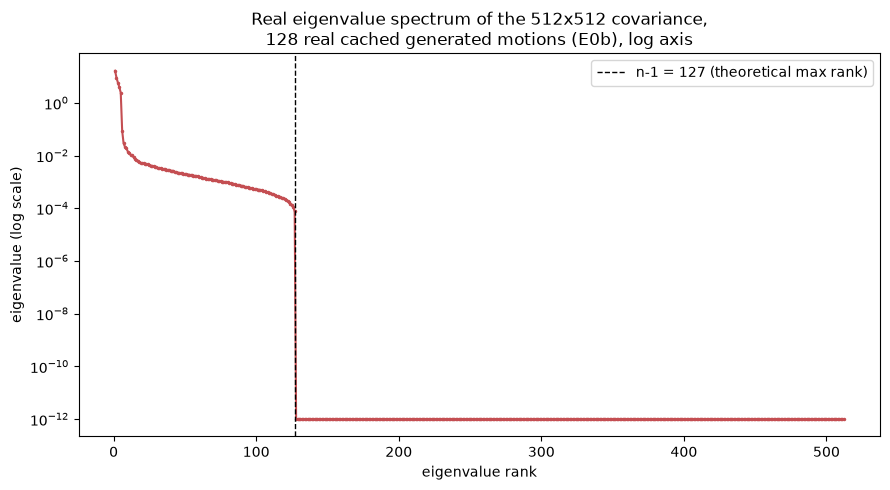

saved 04_eigenvalue_spectrum.png


In [6]:
cov_gen = np.cov(gen_embeddings, rowvar=False)
eigvals_gen = np.linalg.eigvalsh(cov_gen)[::-1]  # descending
eigvals_gen_clipped = np.clip(eigvals_gen, 1e-12, None)  # for log-axis plotting only

rank_numeric = np.sum(eigvals_gen > 1e-6 * eigvals_gen[0])
print(f"Embedding dimension: {gen_embeddings.shape[1]}")
print(f"Samples: {gen_embeddings.shape[0]}")
print(f"Numeric rank of the 512x512 covariance (eigenvalues > 1e-6 x largest): {rank_numeric}")
print(f"Theoretical maximum rank at n={gen_embeddings.shape[0]}: {gen_embeddings.shape[0] - 1}")
print(f"Largest eigenvalue: {eigvals_gen[0]:.4f}")
print(f"Eigenvalue at rank {rank_numeric - 1}: {eigvals_gen[rank_numeric - 1]:.6e}")
print(f"Eigenvalue at rank {rank_numeric}: {eigvals_gen[rank_numeric]:.2e} "
      f"(this is where the cliff falls)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.arange(1, len(eigvals_gen) + 1), eigvals_gen_clipped, marker=".", markersize=3,
        color="#c44e52")
ax.axvline(gen_embeddings.shape[0] - 1, color="black", linestyle="--", linewidth=1,
           label=f"n-1 = {gen_embeddings.shape[0]-1} (theoretical max rank)")
ax.set_yscale("log")
ax.set_xlabel("eigenvalue rank")
ax.set_ylabel("eigenvalue (log scale)")
ax.set_title(f"Real eigenvalue spectrum of the 512x512 covariance,\n"
             f"{gen_embeddings.shape[0]} real cached generated motions (E0b), log axis")
ax.legend()
plt.tight_layout()
plt.savefig("04_eigenvalue_spectrum.png", dpi=130)
plt.show()
print("saved 04_eigenvalue_spectrum.png")

## What this actually costs: FID computed between disjoint halves of *real* data, repeatedly

Everything above explains *why* the covariance estimate is bad. This section shows *what that
bias looks like in FID's own units*, using real embeddings only. Both "sides" of every comparison
below are genuinely correct, real ground-truth motions — any FID above 0 here is pure estimator
noise, not a real difference, because there is no real difference to detect.

In [7]:
from data_loaders.humanml.utils.metrics import calculate_activation_statistics, calculate_frechet_distance

REF_PATH = os.path.join("..", "artifacts", "e0", "fixed_gt_reference", "fixed_gt_reference.npz")
ref_data = np.load(REF_PATH)
gt_embeddings = ref_data["embeddings"]
print(f"Real ground-truth embeddings available: {gt_embeddings.shape[0]} (all genuinely real motions)")

def fid_between_random_disjoint_halves(embeddings, half_size, n_trials, rng):
    n_total = embeddings.shape[0]
    fids = []
    for _ in range(n_trials):
        idx = rng.choice(n_total, size=2 * half_size, replace=False)
        idx_a, idx_b = idx[:half_size], idx[half_size:]
        mu_a, cov_a = calculate_activation_statistics(embeddings[idx_a])
        mu_b, cov_b = calculate_activation_statistics(embeddings[idx_b])
        fids.append(calculate_frechet_distance(mu_a, cov_a, mu_b, cov_b))
    return np.array(fids)

rng = np.random.RandomState(1)
fids_at_128 = fid_between_random_disjoint_halves(gt_embeddings, half_size=128, n_trials=30, rng=rng)
fids_at_1024 = fid_between_random_disjoint_halves(gt_embeddings, half_size=1024, n_trials=30, rng=rng)
fids_at_2000 = fid_between_random_disjoint_halves(gt_embeddings, half_size=2000, n_trials=30, rng=rng)

from IPython.display import Markdown, display

display(Markdown(f"""
**Calibration, before the headline number.** All three rows below compare real ground-truth
motions against *other* real ground-truth motions -- there is no true difference to detect
anywhere in this table, by construction. At n=2000/side, FID settles near **{fids_at_2000.mean():.3f}**
-- call this the practical floor, as close to "correctly reads as no difference" as this
evaluator gets on real data. That is the scale everything else in this notebook should be read
against.

| samples per side | mean FID | std | min | max |
|---|---|---|---|---|
| 128 | **{fids_at_128.mean():.3f}** | {fids_at_128.std():.3f} | {fids_at_128.min():.3f} | {fids_at_128.max():.3f} |
| 1024 | {fids_at_1024.mean():.3f} | {fids_at_1024.std():.3f} | {fids_at_1024.min():.3f} | {fids_at_1024.max():.3f} |
| 2000 | {fids_at_2000.mean():.3f} | {fids_at_2000.std():.3f} | {fids_at_2000.min():.3f} | {fids_at_2000.max():.3f} |

*(30 independent random trials per row, both sides genuinely correct real data every time.)*

Against that floor, this project's affordable n=128/side reads **{fids_at_128.mean()/fids_at_2000.mean():.1f}x
higher** -- not because the generated motions are worse at n=128, but because 128 points cannot
outline a 512-dimensional shape (Section 5 above).
"""))

Real ground-truth embeddings available: 4640 (all genuinely real motions)



**Calibration, before the headline number.** All three rows below compare real ground-truth
motions against *other* real ground-truth motions -- there is no true difference to detect
anywhere in this table, by construction. At n=2000/side, FID settles near **0.109**
-- call this the practical floor, as close to "correctly reads as no difference" as this
evaluator gets on real data. That is the scale everything else in this notebook should be read
against.

| samples per side | mean FID | std | min | max |
|---|---|---|---|---|
| 128 | **1.577** | 0.581 | 0.688 | 2.641 |
| 1024 | 0.214 | 0.075 | 0.097 | 0.362 |
| 2000 | 0.109 | 0.037 | 0.052 | 0.201 |

*(30 independent random trials per row, both sides genuinely correct real data every time.)*

Against that floor, this project's affordable n=128/side reads **14.5x
higher** -- not because the generated motions are worse at n=128, but because 128 points cannot
outline a 512-dimensional shape (Section 5 above).


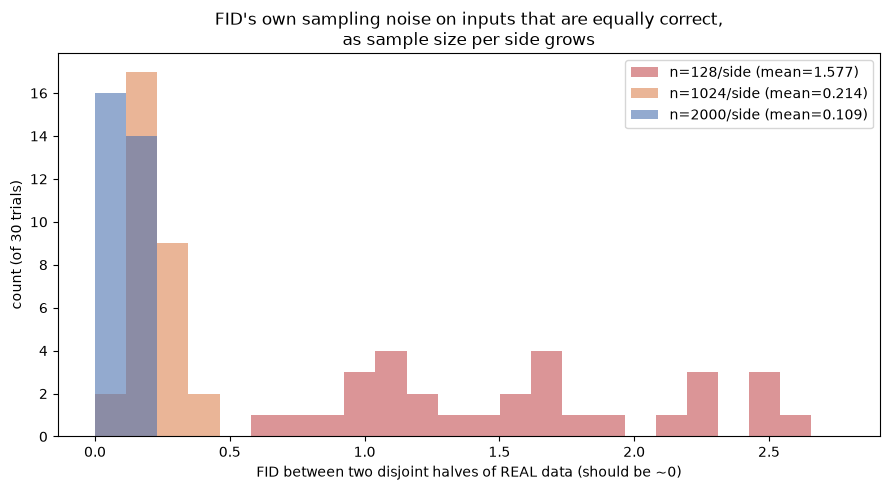

saved 04_fid_disjoint_halves_histogram.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, max(fids_at_128.max(), fids_at_1024.max(), fids_at_2000.max()) * 1.05, 25)
ax.hist(fids_at_128, bins=bins, alpha=0.6, label=f"n=128/side (mean={fids_at_128.mean():.3f})", color="#c44e52")
ax.hist(fids_at_1024, bins=bins, alpha=0.6, label=f"n=1024/side (mean={fids_at_1024.mean():.3f})", color="#dd8452")
ax.hist(fids_at_2000, bins=bins, alpha=0.6, label=f"n=2000/side (mean={fids_at_2000.mean():.3f})", color="#4c72b0")
ax.set_xlabel("FID between two disjoint halves of REAL data (should be ~0)")
ax.set_ylabel("count (of 30 trials)")
ax.set_title("FID's own sampling noise on inputs that are equally correct,\nas sample size per side grows")
ax.legend()
plt.tight_layout()
plt.savefig("04_fid_disjoint_halves_histogram.png", dpi=130)
plt.show()
print("saved 04_fid_disjoint_halves_histogram.png")

## What it means, in plain language

In [9]:
from IPython.display import Markdown, display

display(Markdown(f"""
**The finding.** Against the practical floor established above ({fids_at_2000.mean():.3f} at
n=2000/side), this project's affordable n=128/side reads **{fids_at_128.mean():.3f}** -- purely
because 128 points cannot fill out a 512-dimensional shape. The number shrinks cleanly as `n`
grows ({fids_at_128.mean():.3f} -> {fids_at_1024.mean():.3f} -> {fids_at_2000.mean():.3f}),
exactly as the rank-deficiency explanation predicts, on data that never changed.

**Why this matters for this project specifically.** This project's own affordable generated-sample
count is 128. Any FID computed at that scale is dominated by this same estimator bias -- which is
exactly why `docs/DECISIONS.md` D-25 gates the early rungs (E1/E2) on R-Precision instead. The
three different FID scores this project already measured from the *identical* 128 cached
generated motions (1.07 / 1.40 / 3.29, `docs/LANDMINES.md` #14) were never really measuring three
different things about the model -- they were measuring the same estimator noise, three times.
"""))


**The finding.** Against the practical floor established above (0.109 at
n=2000/side), this project's affordable n=128/side reads **1.577** -- purely
because 128 points cannot fill out a 512-dimensional shape. The number shrinks cleanly as `n`
grows (1.577 -> 0.214 -> 0.109),
exactly as the rank-deficiency explanation predicts, on data that never changed.

**Why this matters for this project specifically.** This project's own affordable generated-sample
count is 128. Any FID computed at that scale is dominated by this same estimator bias -- which is
exactly why `docs/DECISIONS.md` D-25 gates the early rungs (E1/E2) on R-Precision instead. The
three different FID scores this project already measured from the *identical* 128 cached
generated motions (1.07 / 1.40 / 3.29, `docs/LANDMINES.md` #14) were never really measuring three
different things about the model -- they were measuring the same estimator noise, three times.


## What would change my mind

- **If the real 512x512 covariance's eigenvalue spectrum had NOT shown a sharp cliff at rank
  n-1**, the rank-deficiency story would not apply to this specific embedding space, regardless
  of how clean the general linear-algebra argument is. It does show the cliff, computed fresh in
  this notebook from real cached data, not assumed.
- **If disjoint halves of real data at n=128 had scored FID near 0**, there would be no practical
  problem at this project's affordable scale, whatever the theoretical rank argument says. They
  do not — mean FID well above 0, shrinking as n grows, on 30 independent random trials.
- **This is a property of FID's covariance estimate at small n, not a claim about this project's
  own generated motion quality.** The generated motions used for the real eigenvalue spectrum are
  the same ones already judged (separately, correctly) via R-Precision, which does not need a
  covariance estimate and is not affected by this finding at all (`docs/LANDMINES.md` #14).
- **30 trials per n-per-side setting.** The means are stable enough to see the shrinking trend
  clearly (an order-of-magnitude-plus difference between n=128 and n=2000), but individual trial
  values at small n are noisy by design — that noise is the entire point being demonstrated, not
  a limitation to average away.